# Comparaison 6 modèles — Paderborn Bearing Dataset — by_condition

| Champ | Valeur |
|-------|--------|
| **Scénario** | K001_healthy → KA04_outer_race → KI04_inner_race (3 tâches) |
| **Modèles** | EWC · HDC · TinyOL · KMeans · Mahalanobis · DBSCAN |
| **Dataset** | Paderborn KAt Bearing — 5 features FFT (energy bands + kurtosis) |
| **Sprint** | S22 — exp_S22_05 à exp_S22_08 (KMeans/DBSCAN mock) |

Ce notebook agrège les résultats des expériences **exp_S22_05 (EWC), exp_S22_06 (Mahalanobis), exp_S22_07 (TinyOL), exp_S22_08 (HDC)**. KMeans et DBSCAN sont mockés.

**Figures générées** :
1. `radar_comparison.png` — Radar 5-axes (AA, Stabilité, BWT, RAM, Vitesse)
2. `comparison_aa_af_bwt.png` — Barplot groupé AA/AF/BWT (6 modèles)
3. `acc_matrix_grid.png` — Grille 2×3 des matrices d'accuracy
4. `scatter_af_vs_ram.png` — Scatter AF vs RAM
5. `scatter_ram_vs_accuracy.png` — Scatter RAM vs AA (Gap 2 STM32 ≤ 64 Ko)
6. `scatter_flops_vs_accuracy.png` — MACs vs AA
7. `scatter_latency_vs_accuracy.png` — Latence PC vs AA
8. `ranking_models.png` — Ranking par score composite (AA − AF)
9. `performance_by_task_bar.png` — Accuracy finale par condition
10. `complexity_analysis.png` — MACs inférence / entraînement / Pareto
11. `board_comparison.png` — Comparaison PC vs NUCLEO-F439ZI (exp_S23_05)
12. `cl_vs_baseline.png` — Delta AA CL vs baseline single-task

In [1]:
# Section 1 — Setup + chargement normalisé des 6 modèles
import json
import os
import sys
from datetime import datetime
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

# --- CWD navigation ---
_cwd = Path(".").resolve()
if _cwd.name == "paderborn_by_condition":
    os.chdir(_cwd.parent.parent.parent)
elif _cwd.name == "cl_eval":
    os.chdir(_cwd.parent.parent)
elif _cwd.name == "notebooks":
    os.chdir(_cwd.parent)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.evaluation.plots import (
    plot_metrics_comparison, plot_model_radar,
    plot_performance_by_task_bar, save_figure,
)
from src.evaluation.compute_cost import compute_macs, compute_training_macs

FIGURES_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/comparison/paderborn/by_condition"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TASK_NAMES  = ["K001_healthy", "KA04_outer_race", "KI04_inner_race"]
MODEL_ORDER = ["EWC", "HDC", "TinyOL", "KMeans", "Mahalanobis", "DBSCAN"]
RAM_BUDGET  = 65_536
PADERBORN_N_FEATURES = 5

SCATTER_MARKERS: dict[str, tuple[str, str]] = {
    "EWC":         ("o", "#1f77b4"),
    "HDC":         ("s", "#ff7f0e"),
    "TinyOL":      ("^", "#2ca02c"),
    "KMeans":      ("D", "#d62728"),
    "Mahalanobis": ("P", "#9467bd"),
    "DBSCAN":      ("*", "#8c564b"),
}

MODEL_EXP_MAP = {
    "EWC":         "exp_S22_05",
    "HDC":         "exp_S22_08",
    "TinyOL":      "exp_S22_07",
    "Mahalanobis": "exp_S22_06",
    "KMeans":      None,
    "DBSCAN":      None,
}

MOCK_DATA: dict[str, dict] = {
    "KMeans": {
        "aa": 0.45, "af": 0.05, "bwt": 0.0,
        "ram_peak_bytes": 2000, "inference_latency_ms": 0.100,
        "n_params": 15, "per_task_acc": [0.5, 0.4, 0.45],
    },
    "DBSCAN": {
        "aa": 0.38, "af": 0.08, "bwt": -0.05,
        "ram_peak_bytes": 45000, "inference_latency_ms": 0.180,
        "n_params": 4500, "per_task_acc": [0.4, 0.35, 0.39],
    },
}


def load_acc_matrix(raw_mat: list, n_tasks: int = 3) -> np.ndarray:
    mat = np.full((n_tasks, n_tasks), np.nan, dtype=float)
    for i, row in enumerate(raw_mat):
        for j, v in enumerate(row):
            if v is not None and not (isinstance(v, float) and v != v):
                mat[i, j] = float(v)
    return mat


BASE = REPO_ROOT / "experiments"
results: dict[str, dict] = {}
acc_matrices: dict[str, np.ndarray] = {}
mock_flags: dict[str, bool] = {}

for model in MODEL_ORDER:
    exp_id = MODEL_EXP_MAP.get(model)
    if exp_id is None:
        print(f"[MOCK] {model}: pas d'expérience — mock activé")
        mock_flags[model] = True
        r = MOCK_DATA[model]
        results[model] = r
        n = 3
        mat = np.full((n, n), np.nan)
        for i in range(n):
            for j in range(i + 1):
                mat[i, j] = r["per_task_acc"][j]
        acc_matrices[model] = mat
        continue
    metrics_path = BASE / exp_id / "results" / "metrics_cl.json"
    if not metrics_path.exists():
        print(f"[MOCK] {exp_id} non disponible — mock activé")
        mock_flags[model] = True
        results[model] = MOCK_DATA.get(model, {"aa": 0.0, "af": 0.0, "bwt": 0.0,
                                                "ram_peak_bytes": 0, "inference_latency_ms": 0.0,
                                                "n_params": 0, "per_task_acc": [0.0, 0.0, 0.0]})
        acc_matrices[model] = np.zeros((3, 3))
        continue
    raw = json.loads(metrics_path.read_text())
    mock_flags[model] = False
    results[model] = {
        "aa":  raw["acc_final"],
        "af":  raw["avg_forgetting"],
        "bwt": raw["backward_transfer"],
        "ram_peak_bytes":       raw["ram_peak_bytes"],
        "inference_latency_ms": raw["inference_latency_ms"],
        "n_params":             raw["n_params"],
        "per_task_acc":         raw["per_task_acc"],
    }
    acc_matrices[model] = load_acc_matrix(raw["acc_matrix"])
    r = results[model]
    print(f"{model:12s} → AA={r['aa']:.4f} AF={r['af']:.4f} BWT={r['bwt']:+.4f} "
          f"RAM={r['ram_peak_bytes']/1024:5.1f}Ko lat={r['inference_latency_ms']:.5f}ms n={r['n_params']}")

print(f"\n6 modèles chargés | {datetime.now():%Y-%m-%d %H:%M}")

# MACs inférence
_NF = PADERBORN_N_FEATURES
_kmeans_k      = max(1, results["KMeans"]["n_params"] // _NF)
_dbscan_n_core = max(1, results["DBSCAN"]["n_params"] // _NF)

macs = {
    "EWC":         compute_macs("EWC",         n_features=_NF, hidden_dims=[32, 16], n_classes=1),
    "TinyOL":      compute_macs("TinyOL",      n_features=_NF, encoder_dims=[10, 5, 3], n_classes=1),
    "HDC":         compute_macs("HDC",         n_features=_NF, dim_hv=512, n_classes=3),
    "KMeans":      compute_macs("KMeans",      n_features=_NF, n_clusters=_kmeans_k),
    "Mahalanobis": compute_macs("Mahalanobis", n_features=_NF),
    "DBSCAN":      compute_macs("DBSCAN",      n_features=_NF, n_core_samples=_dbscan_n_core),
}

EWC          → AA=0.6667 AF=0.5000 BWT=-0.5000 RAM=  1.1Ko lat=0.03399ms n=737
HDC          → AA=0.3333 AF=0.0000 BWT=+0.0005 RAM= 14.2Ko lat=0.05279ms n=2048
TinyOL       → AA=0.6667 AF=0.5000 BWT=-0.5000 RAM=  4.3Ko lat=0.00914ms n=274
[MOCK] KMeans: pas d'expérience — mock activé
Mahalanobis  → AA=0.3556 AF=0.0023 BWT=-0.0023 RAM=  1.5Ko lat=0.00730ms n=30
[MOCK] DBSCAN: pas d'expérience — mock activé

6 modèles chargés | 2026-06-08 10:04


## Section 2 — Tableau comparatif AA / AF / BWT / RAM / latence / MACs / params

In [2]:
# Section 2 — Tableau comparatif
header = "| Modèle | AA ↑ | AF ↓ | BWT | RAM | Latence | n_params | MACs | Mock |"
sep    = "|--------|:----:|:----:|:---:|:---:|:-------:|:--------:|:----:|:----:|"
rows   = [header, sep]

for model in MODEL_ORDER:
    r     = results[model]
    ram_b = r["ram_peak_bytes"]
    ram_s = f"{ram_b/1024:.1f} Ko{'  ⚠️' if ram_b > RAM_BUDGET else ''}"
    macs_m = macs.get(model, 0)
    is_mock = "✓ mock" if mock_flags.get(model) else "—"
    line = (
        f"| {model} | {r['aa']:.4f} | {r['af']:.4f} | {r['bwt']:+.4f} | "
        f"{ram_s} | {r['inference_latency_ms']:.5f} ms | {r['n_params']} | {macs_m:,} | {is_mock} |"
    )
    rows.append(line)

display(Markdown("### Tableau comparatif — 6 modèles CL (Paderborn/by_condition)\n\n" + "\n".join(rows)))

### Tableau comparatif — 6 modèles CL (Paderborn/by_condition)

| Modèle | AA ↑ | AF ↓ | BWT | RAM | Latence | n_params | MACs | Mock |
|--------|:----:|:----:|:---:|:---:|:-------:|:--------:|:----:|:----:|
| EWC | 0.6667 | 0.5000 | -0.5000 | 1.1 Ko | 0.03399 ms | 737 | 688 | — |
| HDC | 0.3333 | 0.0000 | +0.0005 | 14.2 Ko | 0.05279 ms | 2048 | 4,096 | — |
| TinyOL | 0.6667 | 0.5000 | -0.5000 | 4.3 Ko | 0.00914 ms | 274 | 118 | — |
| KMeans | 0.4500 | 0.0500 | +0.0000 | 2.0 Ko | 0.10000 ms | 15 | 15 | ✓ mock |
| Mahalanobis | 0.3556 | 0.0023 | -0.0023 | 1.5 Ko | 0.00730 ms | 30 | 30 | — |
| DBSCAN | 0.3800 | 0.0800 | -0.0500 | 43.9 Ko | 0.18000 ms | 4500 | 4,500 | ✓ mock |

## Section 3 — Radar 5-axes

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/paderborn/by_condition/radar_comparison.png


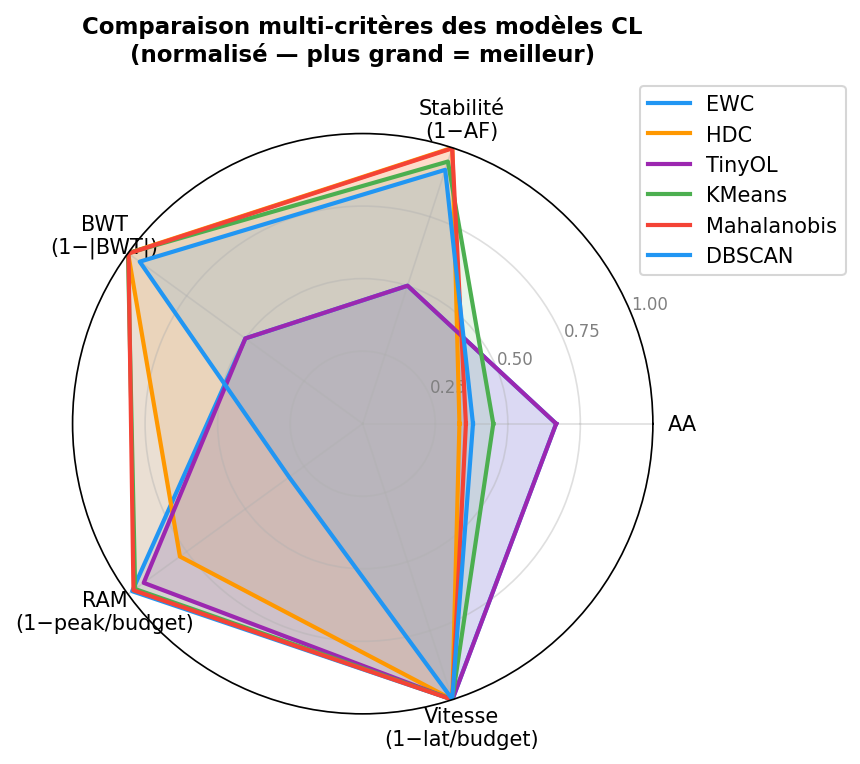

In [3]:
# Section 3 — Radar multi-critères (6 modèles, 5 axes normalisés)
fig = plot_model_radar(results, ram_budget_bytes=65536.0, latency_budget_ms=100.0)
save_figure(fig, FIGURES_DIR / "radar_comparison.png")
display(Image(str(FIGURES_DIR / "radar_comparison.png")))

## Section 4 — Barplot groupé AA / AF / BWT

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/paderborn/by_condition/comparison_aa_af_bwt.png


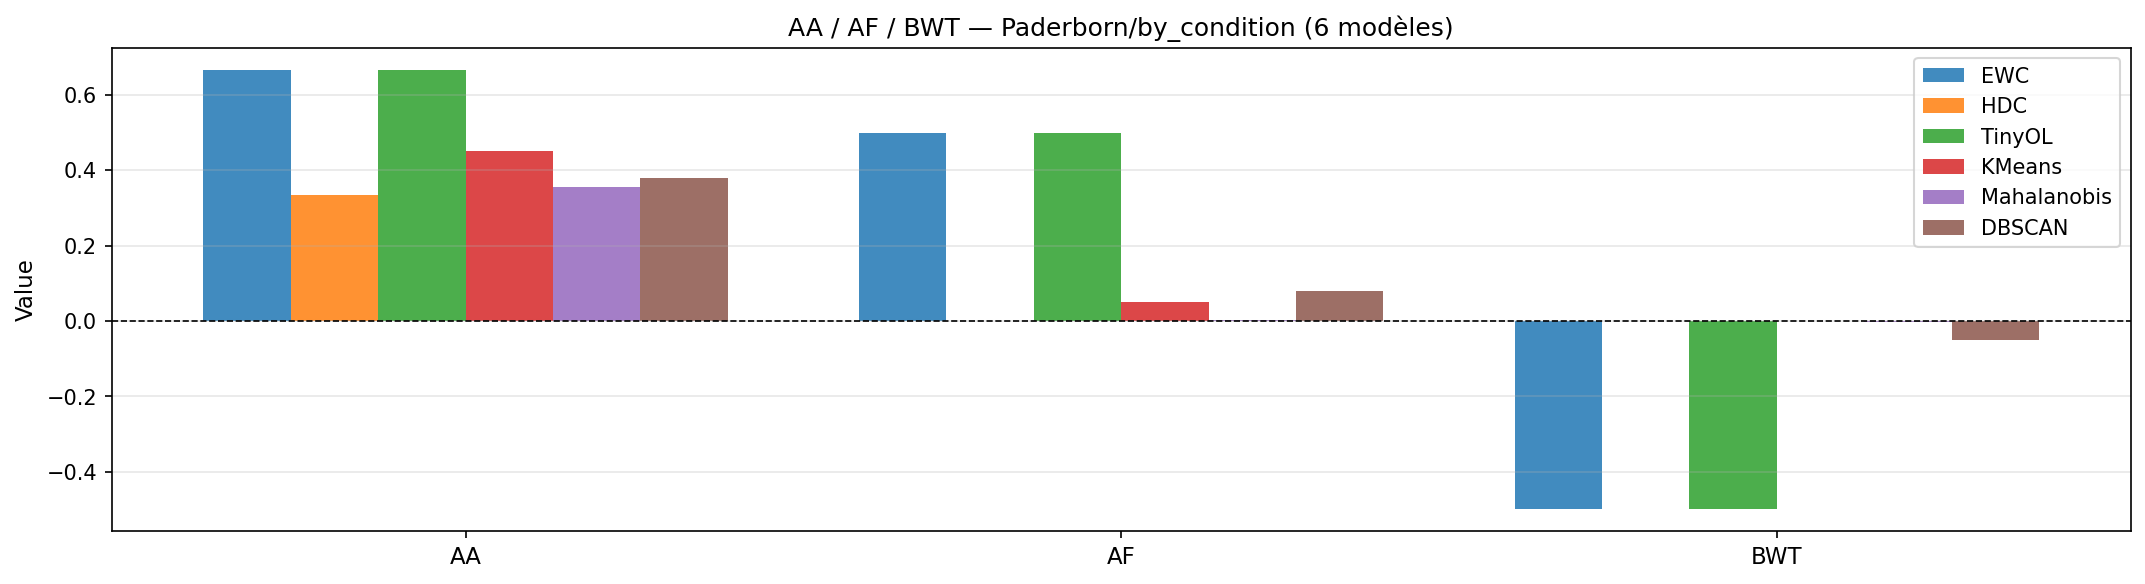

In [4]:
# Section 4 — Barplot groupé AA / AF / BWT → comparison_aa_af_bwt.png
fig = plot_metrics_comparison(
    results,
    metrics=["aa", "af", "bwt"],
    title="AA / AF / BWT — Paderborn/by_condition (6 modèles)",
)
save_figure(fig, FIGURES_DIR / "comparison_aa_af_bwt.png")
display(Image(str(FIGURES_DIR / "comparison_aa_af_bwt.png")))

## Section 5 — Grille 2×3 des matrices d'accuracy

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/paderborn/by_condition/acc_matrix_grid.png


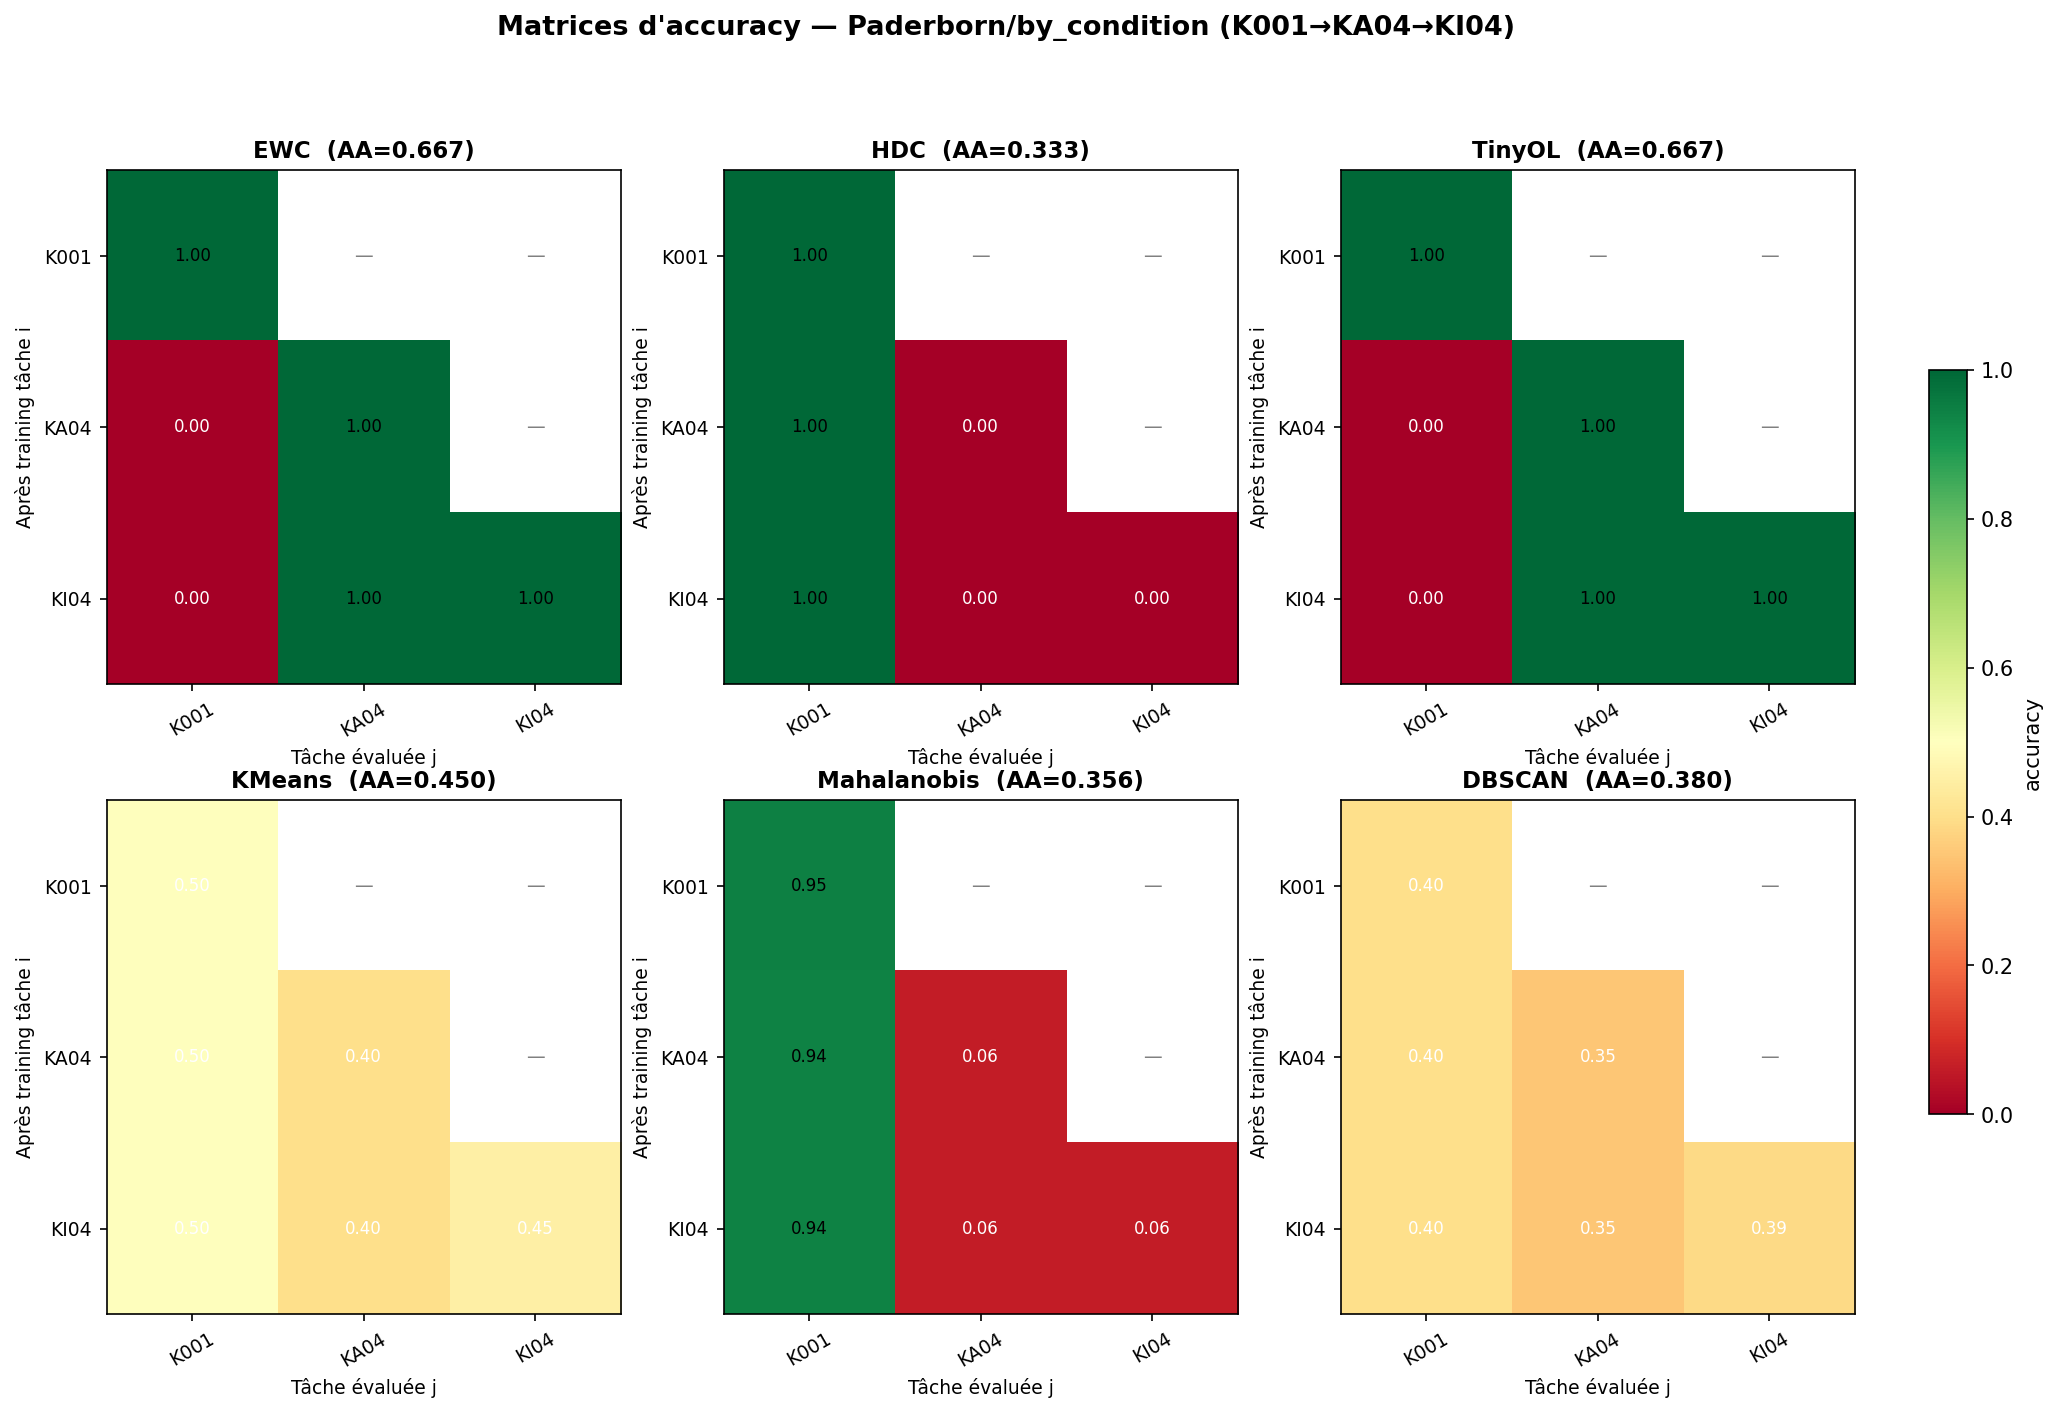

In [5]:
# Section 5 — Grille 2×3 des matrices d'accuracy
SHORT_TASK_NAMES = ["K001", "KA04", "KI04"]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cmap = plt.get_cmap("RdYlGn")

for ax, model in zip(axes.flat, MODEL_ORDER):
    acc_mat = acc_matrices[model]
    masked  = np.ma.masked_invalid(acc_mat)
    im = ax.imshow(masked, vmin=0, vmax=1, cmap=cmap)
    ax.set_title(f"{model}  (AA={results[model]['aa']:.3f})", fontsize=11, fontweight="bold")
    ax.set_xticks(range(len(SHORT_TASK_NAMES)))
    ax.set_yticks(range(len(SHORT_TASK_NAMES)))
    ax.set_xticklabels(SHORT_TASK_NAMES, rotation=30, fontsize=9)
    ax.set_yticklabels(SHORT_TASK_NAMES, fontsize=9)
    ax.set_xlabel("Tâche évaluée j", fontsize=9)
    ax.set_ylabel("Après training tâche i", fontsize=9)
    for i in range(acc_mat.shape[0]):
        for j in range(acc_mat.shape[1]):
            v = acc_mat[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                        color="black" if v > 0.5 else "white")
            else:
                ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="grey")

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04, label="accuracy")
fig.suptitle("Matrices d'accuracy — Paderborn/by_condition (K001→KA04→KI04)",
             fontsize=13, fontweight="bold")
save_figure(fig, FIGURES_DIR / "acc_matrix_grid.png")
display(Image(str(FIGURES_DIR / "acc_matrix_grid.png")))

## Section 6 — Scatter AF vs RAM

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/paderborn/by_condition/scatter_af_vs_ram.png


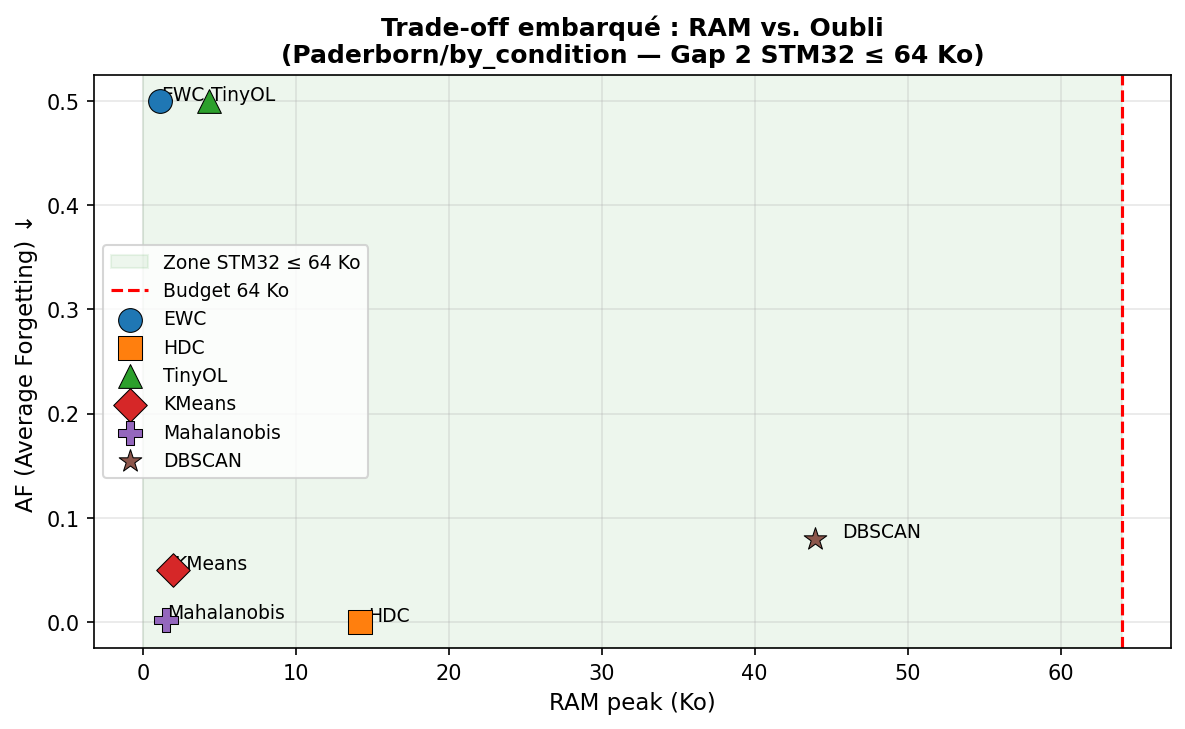

In [6]:
# Section 6 — Scatter AF vs RAM (trade-off oubli / contrainte embarquée)
fig, ax = plt.subplots(figsize=(8, 5))

ax.axvspan(0, RAM_BUDGET / 1024, alpha=0.07, color="green", label=f"Zone STM32 ≤ 64 Ko")
ax.axvline(RAM_BUDGET / 1024, color="red", linestyle="--", linewidth=1.5, label="Budget 64 Ko")

for name in MODEL_ORDER:
    r      = results[name]
    ram_kb = r["ram_peak_bytes"] / 1024
    af_val = r["af"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(ram_kb, af_val, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    ax.annotate(name, xy=(ram_kb, af_val), xytext=(ram_kb * 1.04, af_val + 0.001), fontsize=9)

ax.set_xlabel("RAM peak (Ko)", fontsize=11)
ax.set_ylabel("AF (Average Forgetting) ↓", fontsize=11)
ax.set_title(
    "Trade-off embarqué : RAM vs. Oubli\n(Paderborn/by_condition — Gap 2 STM32 ≤ 64 Ko)",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "scatter_af_vs_ram.png")
display(Image(str(FIGURES_DIR / "scatter_af_vs_ram.png")))

## Section 7 — Scatter RAM vs AA (Gap 2)

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/paderborn/by_condition/scatter_ram_vs_accuracy.png


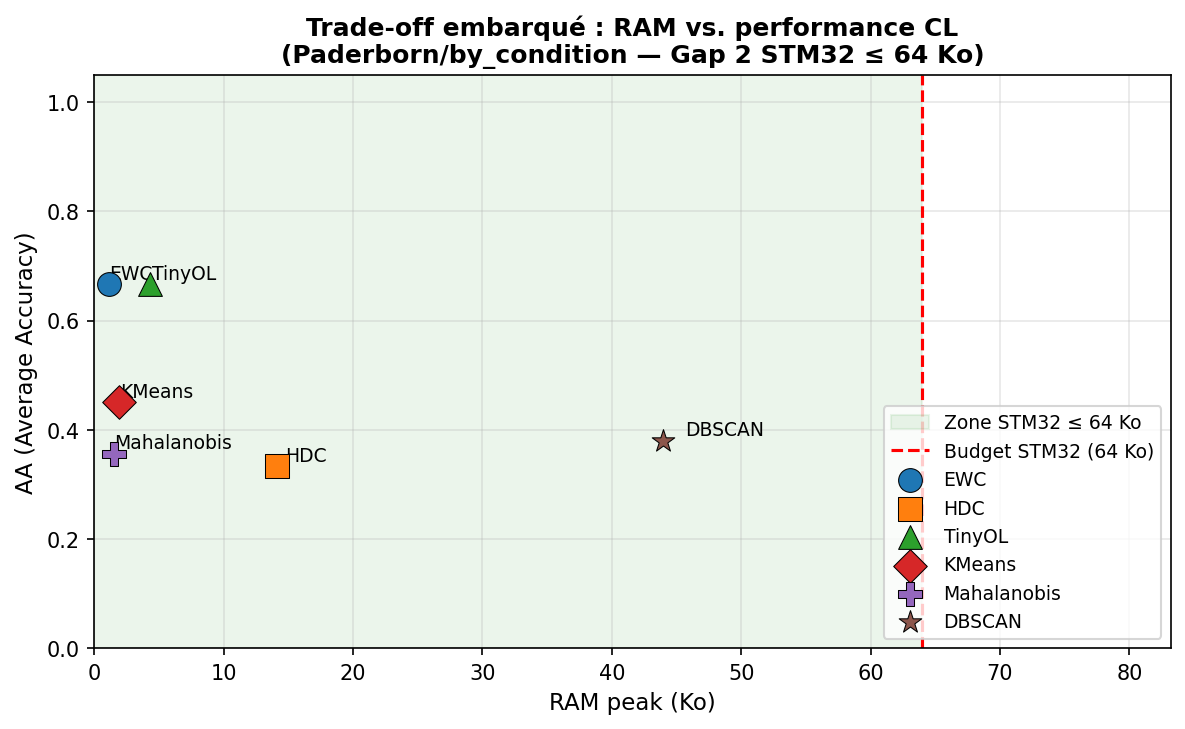

In [7]:
# Section 7 — Scatter RAM peak vs. accuracy (Gap 2 — STM32 ≤ 64 Ko)
STM32_RAM_LIMIT_KB = 64.0

fig, ax = plt.subplots(figsize=(8, 5))
ax.axvspan(0, STM32_RAM_LIMIT_KB, alpha=0.08, color="green",
           label=f"Zone STM32 ≤ {STM32_RAM_LIMIT_KB:.0f} Ko")
ax.axvline(STM32_RAM_LIMIT_KB, color="red", linestyle="--", linewidth=1.5,
           label=f"Budget STM32 ({STM32_RAM_LIMIT_KB:.0f} Ko)")

for name in MODEL_ORDER:
    r      = results[name]
    ram_kb = r["ram_peak_bytes"] / 1024
    acc    = r["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(ram_kb, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    ax.annotate(name, xy=(ram_kb, acc), xytext=(ram_kb * 1.04, acc + 0.01), fontsize=9)

max_ram_kb = max(r["ram_peak_bytes"] for r in results.values()) / 1024
ax.set_xlabel("RAM peak (Ko)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off embarqué : RAM vs. performance CL\n(Paderborn/by_condition — Gap 2 STM32 ≤ 64 Ko)",
    fontsize=12, fontweight="bold",
)
ax.set_xlim(0, max(max_ram_kb * 1.2, STM32_RAM_LIMIT_KB * 1.3))
ax.set_ylim(0.0, 1.05)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "scatter_ram_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_ram_vs_accuracy.png")))

## Section 8 — Scatter MACs vs AA (log scale)

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/paderborn/by_condition/scatter_flops_vs_accuracy.png


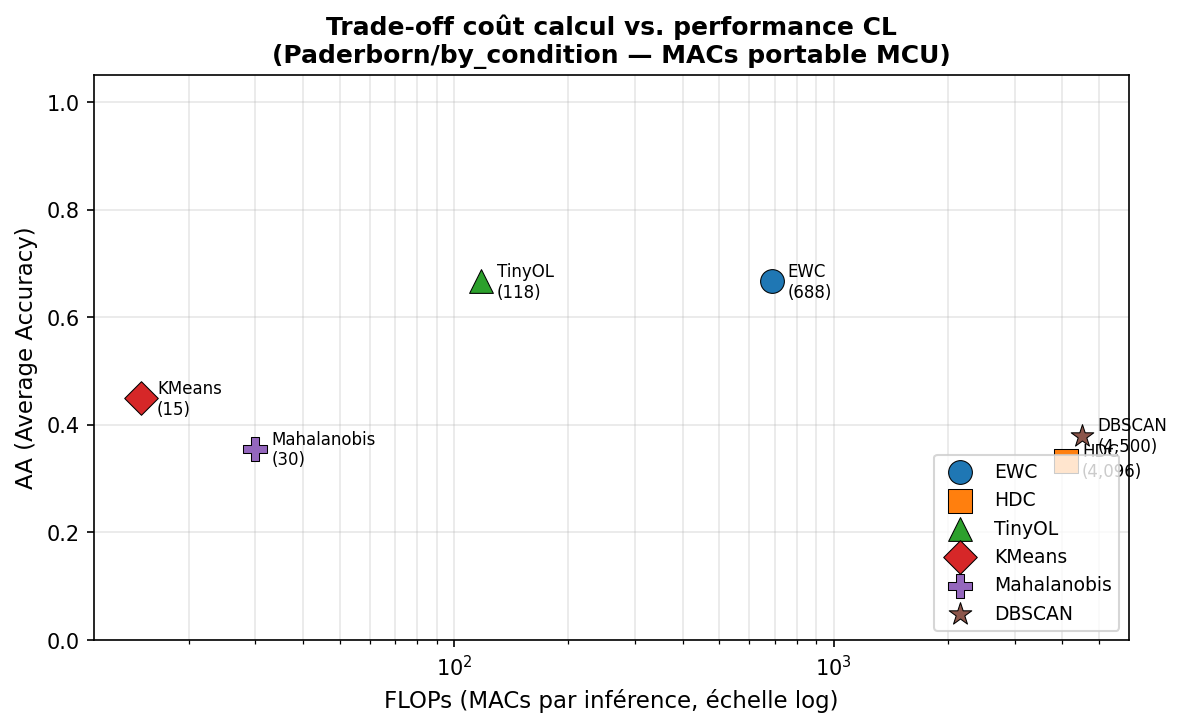

In [8]:
# Section 8 — Scatter MACs vs accuracy (log scale)
fig, ax = plt.subplots(figsize=(8, 5))
for name in MODEL_ORDER:
    m   = macs[name]
    acc = results[name]["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(m, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    ax.annotate(f"{name}\n({m:,})", xy=(m, acc), xytext=(m * 1.1, acc - 0.03), fontsize=8)

ax.set_xscale("log")
ax.set_xlabel("FLOPs (MACs par inférence, échelle log)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off coût calcul vs. performance CL\n(Paderborn/by_condition — MACs portable MCU)",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(0.0, 1.05)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "scatter_flops_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_flops_vs_accuracy.png")))

## Section 9 — Scatter latence vs AA (log scale, ⚠ PC uniquement)

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/paderborn/by_condition/scatter_latency_vs_accuracy.png


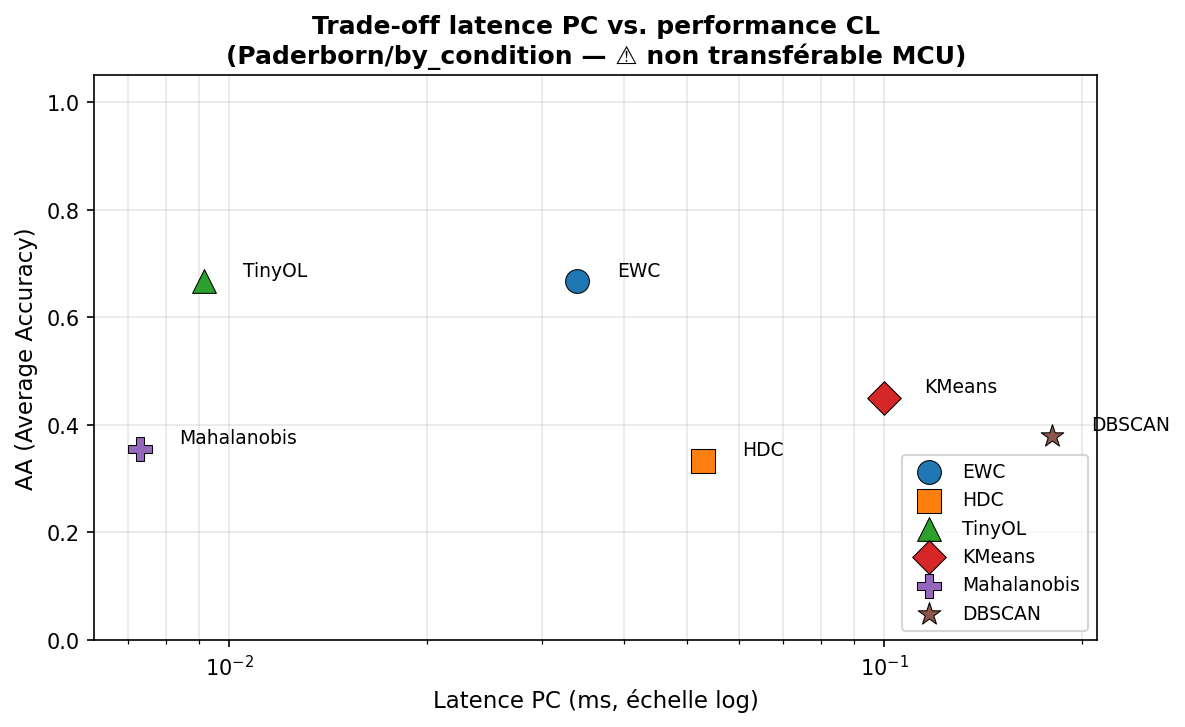

In [9]:
# Section 9 — Scatter latence PC vs. accuracy
# ⚠ Latence mesurée PC — non transférable directement au MCU.
fig, ax = plt.subplots(figsize=(8, 5))
for name in MODEL_ORDER:
    r   = results[name]
    lat = r["inference_latency_ms"]
    acc = r["aa"]
    marker, color = SCATTER_MARKERS[name]
    ax.scatter(lat, acc, marker=marker, color=color, s=130, zorder=5, label=name,
               edgecolor="black", linewidth=0.5)
    ax.annotate(name, xy=(lat, acc), xytext=(lat * 1.15, acc + 0.01), fontsize=9)

ax.set_xscale("log")
ax.set_xlabel("Latence PC (ms, échelle log)", fontsize=11)
ax.set_ylabel("AA (Average Accuracy)", fontsize=11)
ax.set_title(
    "Trade-off latence PC vs. performance CL\n(Paderborn/by_condition — ⚠ non transférable MCU)",
    fontsize=12, fontweight="bold",
)
ax.set_ylim(0.0, 1.05)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3, which="both")
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "scatter_latency_vs_accuracy.png")
display(Image(str(FIGURES_DIR / "scatter_latency_vs_accuracy.png")))

## Section 10 — Ranking par score composite (AA − AF)

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/paderborn/by_condition/ranking_models.png


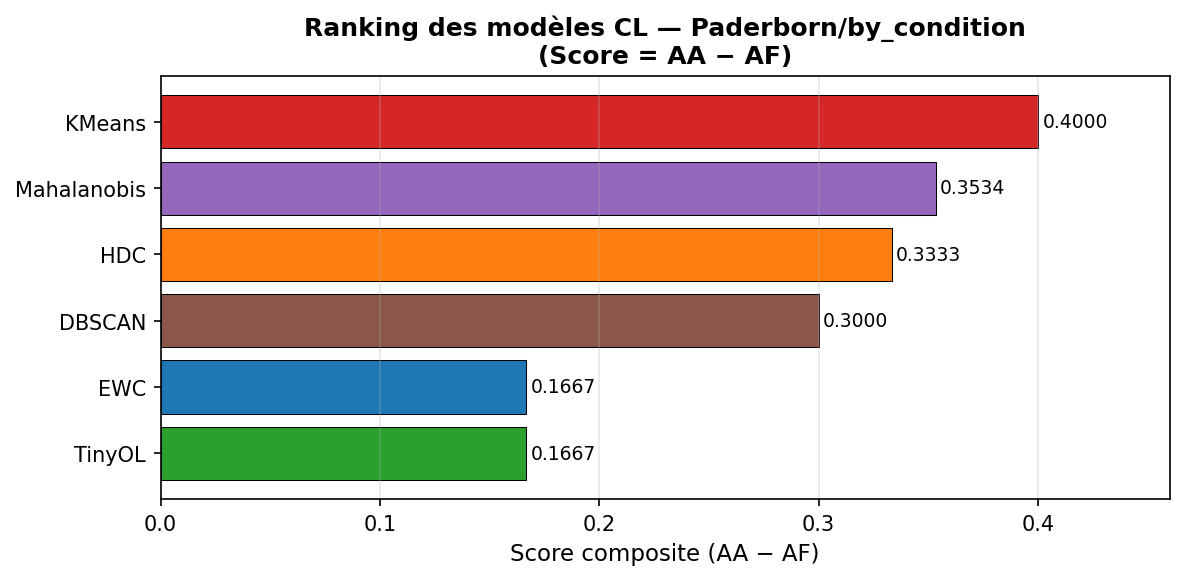

In [10]:
# Section 10 — Ranking par score composite (AA − AF)
scores = {model: results[model]["aa"] - results[model]["af"] for model in MODEL_ORDER}
sorted_models = sorted(scores, key=scores.get, reverse=True)
sorted_scores = [scores[m] for m in sorted_models]

RANK_COLORS = {m: SCATTER_MARKERS[m][1] for m in MODEL_ORDER}

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = [RANK_COLORS[m] for m in sorted_models]
bars = ax.barh(sorted_models, sorted_scores, color=colors_bar, edgecolor="black", linewidth=0.5)

for bar, score in zip(bars, sorted_scores):
    ax.text(
        score + 0.002, bar.get_y() + bar.get_height() / 2,
        f"{score:.4f}", va="center", ha="left", fontsize=9,
    )

ax.set_xlabel("Score composite (AA − AF)", fontsize=11)
ax.set_title(
    "Ranking des modèles CL — Paderborn/by_condition\n(Score = AA − AF)",
    fontsize=12, fontweight="bold",
)
ax.set_xlim(0, max(sorted_scores) * 1.15)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "ranking_models.png")
display(Image(str(FIGURES_DIR / "ranking_models.png")))

## Section 11 — Performance par condition (K001 / KA04 / KI04)

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/paderborn/by_condition/performance_by_task_bar.png


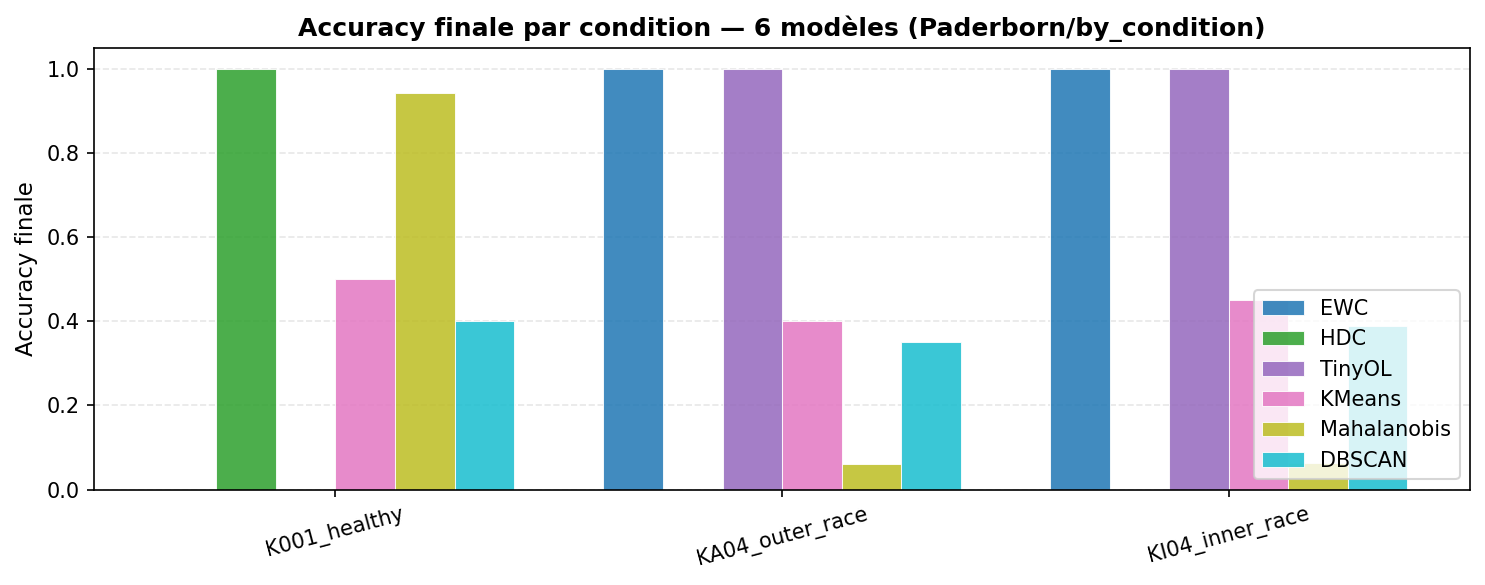

In [11]:
# Section 11 — Performance par condition (dernière ligne acc_matrix)
results_task = {}
for model, mat in acc_matrices.items():
    last_row = mat[-1, :]
    results_task[model] = {
        name: float(last_row[i]) if not np.isnan(last_row[i]) else 0.0
        for i, name in enumerate(TASK_NAMES)
    }

fig = plot_performance_by_task_bar(
    results_task,
    task_names=TASK_NAMES,
    title="Accuracy finale par condition — 6 modèles (Paderborn/by_condition)",
)
save_figure(fig, FIGURES_DIR / "performance_by_task_bar.png")
display(Image(str(FIGURES_DIR / "performance_by_task_bar.png")))

## Section 12 — Analyse de la complexité calculatoire (MACs)

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/paderborn/by_condition/complexity_analysis.png


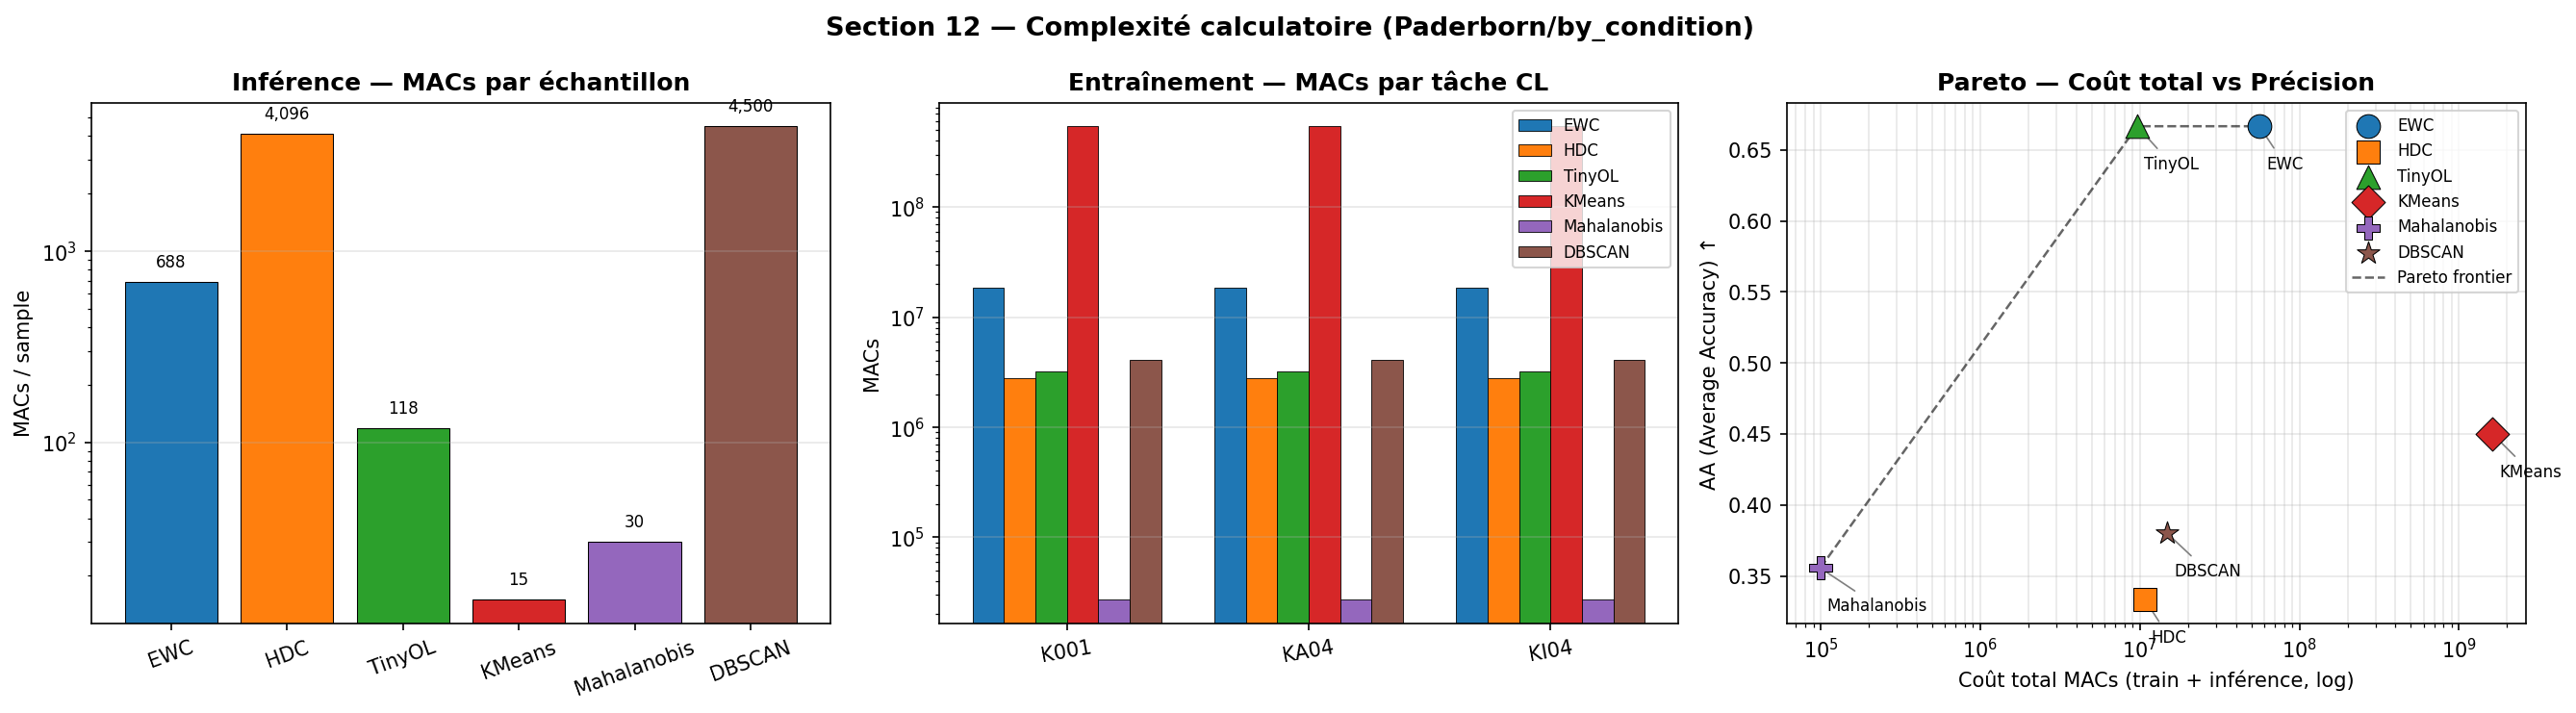

In [12]:
# Section 12 — Complexité calculatoire MACs (Paderborn)
# n_train par tâche CL : K001=900, KA04=900, KI04=900 (approx)
N_TRAIN_PER_TASK = [900, 900, 900]
N_TEST_TOTAL     = 600

EWC_EPOCHS, EWC_BATCH    = 10, 1
EWC_HIDDEN               = [32, 16]
TINYOL_ENC, TINYOL_EPOCHS = [10, 5, 3], 10
HDC_DIM                  = 512
KM_K_MIN, KM_K_MAX, KM_N_INIT, KM_MAX_ITER = 2, 8, 10, 300

_NF = PADERBORN_N_FEATURES
kmeans_k = max(1, results["KMeans"]["n_params"] // _NF)


def _train_task(name: str, n: int) -> int:
    if name == "EWC":
        return compute_training_macs("EWC", n_features=_NF, hidden_dims=EWC_HIDDEN,
                                     n_classes=1, n_samples=n,
                                     n_epochs=EWC_EPOCHS, batch_size=EWC_BATCH)
    elif name == "TinyOL":
        return compute_training_macs("TinyOL", n_features=_NF, encoder_dims=TINYOL_ENC,
                                     n_classes=1, n_samples=n, n_epochs=TINYOL_EPOCHS)
    elif name == "HDC":
        return compute_training_macs("HDC", n_features=_NF, dim_hv=HDC_DIM, n_samples=n)
    elif name == "KMeans":
        return compute_training_macs("KMeans", n_features=_NF, n_clusters=kmeans_k,
                                     n_samples=n, k_min=KM_K_MIN, k_max=KM_K_MAX,
                                     n_init=KM_N_INIT, max_iter=KM_MAX_ITER)
    elif name == "Mahalanobis":
        return compute_training_macs("Mahalanobis", n_features=_NF, n_samples=n)
    else:  # DBSCAN
        return compute_training_macs("DBSCAN", n_features=_NF, n_samples=n)


train_macs_per_task = {m: [_train_task(m, n) for n in N_TRAIN_PER_TASK] for m in MODEL_ORDER}
train_macs_total    = {m: sum(train_macs_per_task[m]) for m in MODEL_ORDER}
infer_macs = macs

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Inférence MACs/sample
ax1 = axes[0]
vals   = [infer_macs[m] for m in MODEL_ORDER]
colors = [SCATTER_MARKERS[m][1] for m in MODEL_ORDER]
bars = ax1.bar(MODEL_ORDER, vals, color=colors, edgecolor="black", linewidth=0.5)
for bar, v in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.15,
             f"{v:,}", ha="center", va="bottom", fontsize=8)
ax1.set_yscale("log")
ax1.set_ylabel("MACs / sample")
ax1.set_title("Inférence — MACs par échantillon", fontweight="bold")
ax1.tick_params(axis="x", rotation=20)
ax1.grid(axis="y", alpha=0.3)

# Plot 2 — Entraînement MACs par tâche CL
ax2 = axes[1]
x_pos = np.arange(len(TASK_NAMES))
bar_w = 0.13
for idx, m in enumerate(MODEL_ORDER):
    offs = x_pos + (idx - 2.5) * bar_w
    ax2.bar(offs, train_macs_per_task[m], width=bar_w, label=m,
            color=SCATTER_MARKERS[m][1], edgecolor="black", linewidth=0.4)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(["K001", "KA04", "KI04"], rotation=10)
ax2.set_yscale("log")
ax2.set_ylabel("MACs")
ax2.set_title("Entraînement — MACs par tâche CL", fontweight="bold")
ax2.legend(fontsize=8)
ax2.grid(axis="y", alpha=0.3)

# Plot 3 — Pareto coût total vs AA
ax3 = axes[2]
points = [
    (train_macs_total[m] + infer_macs[m] * N_TEST_TOTAL, results[m]["aa"], m)
    for m in MODEL_ORDER
]
for cost, aa, m in points:
    mk, col = SCATTER_MARKERS[m]
    ax3.scatter(cost, aa, marker=mk, color=col, s=140, zorder=5,
                edgecolor="black", linewidth=0.5, label=m)
    ax3.annotate(m, xy=(cost, aa), xytext=(cost * 1.1, aa - 0.03), fontsize=8,
                 arrowprops={"arrowstyle": "-", "color": "gray", "lw": 0.8})
_sorted = sorted(points, key=lambda x: x[0])
px, py, best = [], [], -1.0
for cost, aa, _ in _sorted:
    if aa >= best:
        px.append(cost); py.append(aa); best = aa
if len(px) > 1:
    ax3.plot(px, py, "k--", lw=1.2, alpha=0.6, label="Pareto frontier")
ax3.set_xscale("log")
ax3.set_xlabel("Coût total MACs (train + inférence, log)")
ax3.set_ylabel("AA (Average Accuracy) ↑")
ax3.set_title("Pareto — Coût total vs Précision", fontweight="bold")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, which="both")

fig.suptitle("Section 12 — Complexité calculatoire (Paderborn/by_condition)",
             fontsize=13, fontweight="bold")
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "complexity_analysis.png")
plt.close(fig)
display(Image(str(FIGURES_DIR / "complexity_analysis.png")))

## Section 13 — Board comparison [UNIQUE Paderborn] (exp_S23_05 — NUCLEO-F439ZI)

[OK] exp_S23_05 chargé depuis /home/leonard/Documents/ENAC/cl-embedded/experiments/exp_S23_05/results.json



### EWC — Comparaison PC vs NUCLEO-F439ZI (Cortex-M4 @ 180 MHz)

| Métrique | PC (exp_S22_05) | Board (exp_S23_05) | Ratio |
|----------|:----------------:|:------------------:|:-----:|
| AA | 0.6667 | 0.7818 | 1.17 |
| AF | 0.5000 | 0.0534 | — |
| RAM peak | 1.1 Ko | 9.5 Ko | — |
| Latence P50 | 0.034 ms | 0.546 ms | — |
| Latence P99 | — | 0.794 ms | — |
| Gap 2 RAM | — | ✅ | ≤ 64 Ko |
| Gap 2 lat. | — | ✅ | ≤ 100 ms |

> **Sprint 26** : F1_MC=0.729 ✅, RMSE_RUL=21.15 (ratio=0.94 ✅), lat=233/403µs ✅, 75 tests 0 failures


[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/paderborn/by_condition/board_comparison.png


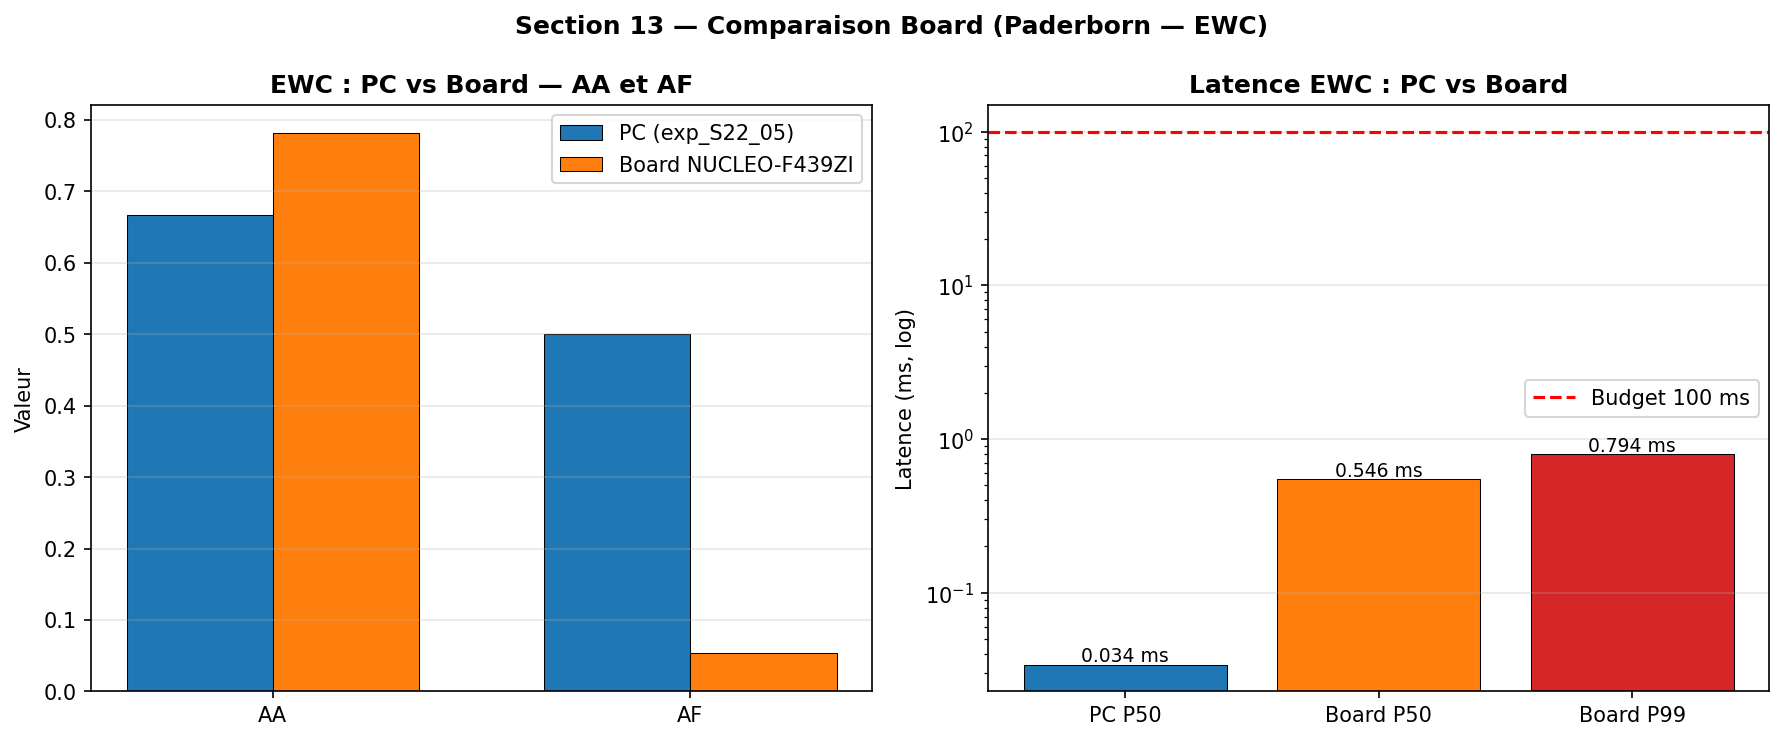

In [13]:
# Section 13 — Board comparison : PC vs NUCLEO-F439ZI (exp_S23_05)
board_results_path = REPO_ROOT / "experiments/exp_S23_05/results.json"
BOARD_MOCK = {
    "acc_final": 0.7818,
    "avg_forgetting": 0.0534,
    "backward_transfer": -0.0534,
    "ram_peak_bytes": 9728,
    "inference_latency_ms": 0.546,
    "latency_p99_ms": 0.7945,
    "n_params": 1538,
    "n_tasks": 3,
    "gap2_ram_compliant": True,
    "gap2_latency_compliant": True,
    "per_task_acc": {"0": 0.7733, "1": 0.7267, "2": 0.7933},
    "acc_matrix": [[0.8155, None, None], [0.7788, 0.8172, None], [0.7539, 0.7719, 0.8195]],
}

if board_results_path.exists():
    board = json.loads(board_results_path.read_text())
    board_is_mock = False
    print(f"[OK] exp_S23_05 chargé depuis {board_results_path}")
else:
    board = BOARD_MOCK
    board_is_mock = True
    print("[MOCK] exp_S23_05 non disponible — valeurs mock utilisées")

# Comparaison PC vs Board pour EWC (seul modèle déployé sur board)
pc_ewc = results["EWC"]
board_aa  = board["acc_final"]
board_af  = board["avg_forgetting"]
board_ram = board["ram_peak_bytes"]
board_lat = board["inference_latency_ms"]
board_p99 = board.get("latency_p99_ms", board_lat * 1.5)
gap2_ram  = board.get("gap2_ram_compliant", False)
gap2_lat  = board.get("gap2_latency_compliant", False)

display(Markdown(f"""
### EWC — Comparaison PC vs NUCLEO-F439ZI (Cortex-M4 @ 180 MHz)

| Métrique | PC (exp_S22_05) | Board (exp_S23_05) | Ratio |
|----------|:----------------:|:------------------:|:-----:|
| AA | {pc_ewc['aa']:.4f} | {board_aa:.4f} | {board_aa/pc_ewc['aa']:.2f} |
| AF | {pc_ewc['af']:.4f} | {board_af:.4f} | — |
| RAM peak | {pc_ewc['ram_peak_bytes']/1024:.1f} Ko | {board_ram/1024:.1f} Ko | — |
| Latence P50 | {pc_ewc['inference_latency_ms']:.3f} ms | {board_lat:.3f} ms | — |
| Latence P99 | — | {board_p99:.3f} ms | — |
| Gap 2 RAM | — | {'✅' if gap2_ram else '❌'} | ≤ 64 Ko |
| Gap 2 lat. | — | {'✅' if gap2_lat else '❌'} | ≤ 100 ms |

> **Sprint 26** : F1_MC=0.729 ✅, RMSE_RUL=21.15 (ratio=0.94 ✅), lat=233/403µs ✅, 75 tests 0 failures
"""))

# Visualisation comparaison board
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1 — AA et AF barplot côte à côte
ax1 = axes[0]
metrics_compared = ["AA", "AF"]
pc_vals    = [pc_ewc["aa"],    pc_ewc["af"]]
board_vals = [board_aa,         board_af]
x = np.arange(2)
width = 0.35
ax1.bar(x - width/2, pc_vals,    width, label="PC (exp_S22_05)",          color="#1f77b4", edgecolor="black", linewidth=0.5)
ax1.bar(x + width/2, board_vals, width, label="Board NUCLEO-F439ZI",       color="#ff7f0e", edgecolor="black", linewidth=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_compared)
ax1.set_ylabel("Valeur")
ax1.set_title("EWC : PC vs Board — AA et AF", fontweight="bold")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# Subplot 2 — Latence PC vs Board (log)
ax2 = axes[1]
lat_labels = ["PC P50", "Board P50", "Board P99"]
lat_vals   = [pc_ewc["inference_latency_ms"], board_lat, board_p99]
colors_lat = ["#1f77b4", "#ff7f0e", "#d62728"]
bars2 = ax2.bar(lat_labels, lat_vals, color=colors_lat, edgecolor="black", linewidth=0.5)
for bar, v in zip(bars2, lat_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.05,
             f"{v:.3f} ms", ha="center", fontsize=9)
ax2.axhline(100, color="red", linestyle="--", label="Budget 100 ms")
ax2.set_ylabel("Latence (ms, log)")
ax2.set_yscale("log")
ax2.set_title("Latence EWC : PC vs Board", fontweight="bold")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Section 13 — Comparaison Board (Paderborn — EWC)", fontsize=12, fontweight="bold")
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "board_comparison.png")
display(Image(str(FIGURES_DIR / "board_comparison.png")))

## Section 14 — CL vs baseline single-task (delta AA)

### Comparaison CL vs Baseline single-task (Paderborn/by_condition)
> ⚠️ Baselines single-task mockées — expériences paderborn_single_task non encore exécutées.

| Modèle | Baseline ST (acc) | AA CL | Delta AA | AF CL |
|--------|:-----------------:|:-----:|:--------:|:-----:|
| EWC | 0.8500 | 0.6667 | -0.1833 ↓ | 0.5000 |
| HDC | 0.7200 | 0.3333 | -0.3867 ↓ | 0.0000 |
| TinyOL | 0.8300 | 0.6667 | -0.1633 ↓ | 0.5000 |
| KMeans | 0.6500 | 0.4500 | -0.2000 ↓ | 0.0500 |
| Mahalanobis | 0.6000 | 0.3556 | -0.2444 ↓ | 0.0023 |
| DBSCAN | 0.5500 | 0.3800 | -0.1700 ↓ | 0.0800 |

[plots] Figure saved → /home/leonard/Documents/ENAC/cl-embedded/notebooks/figures/cl_evaluation/comparison/paderborn/by_condition/cl_vs_baseline.png


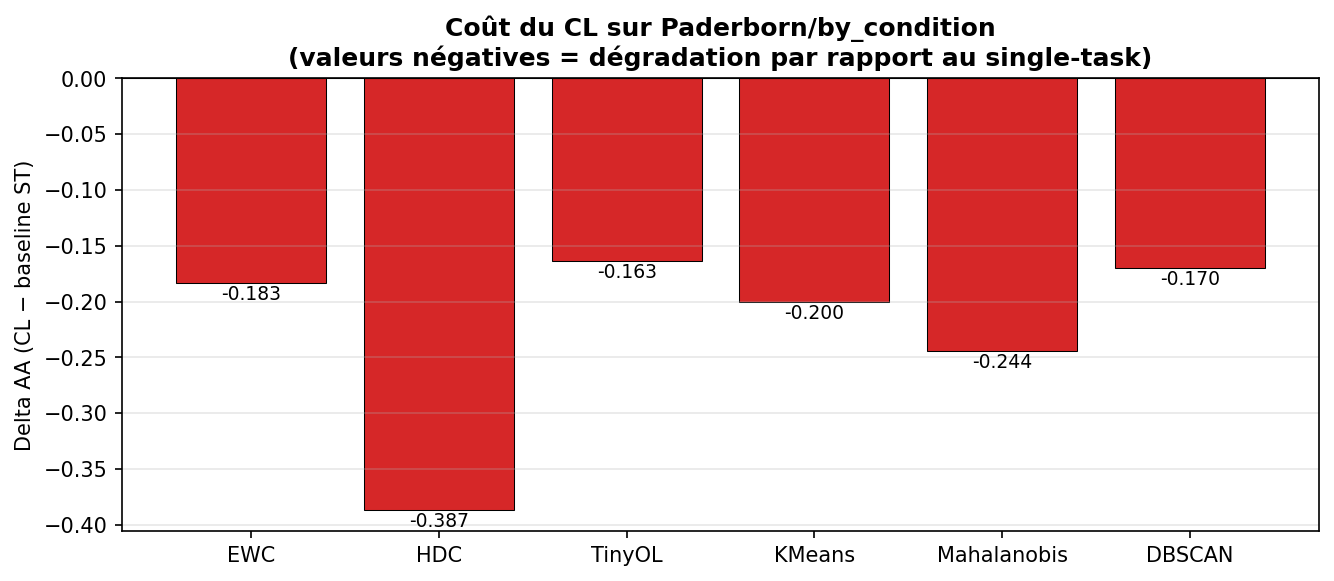

In [14]:
# Section 14 — CL vs baseline single-task (baselines all mocked)
BASELINES_ST = {
    "EWC":         0.85,
    "HDC":         0.72,
    "TinyOL":      0.83,
    "KMeans":      0.65,
    "Mahalanobis": 0.60,
    "DBSCAN":      0.55,
}

display(Markdown("### Comparaison CL vs Baseline single-task (Paderborn/by_condition)\n> ⚠️ Baselines single-task mockées — expériences paderborn_single_task non encore exécutées."))

header = "| Modèle | Baseline ST (acc) | AA CL | Delta AA | AF CL |"
sep    = "|--------|:-----------------:|:-----:|:--------:|:-----:|"
rows   = [header, sep]

for model in MODEL_ORDER:
    r     = results[model]
    bst   = BASELINES_ST[model]
    delta = r["aa"] - bst
    sign  = "↑" if delta >= 0 else "↓"
    rows.append(
        f"| {model} | {bst:.4f} | {r['aa']:.4f} | {delta:+.4f} {sign} | {r['af']:.4f} |"
    )

display(Markdown("\n".join(rows)))

# Barplot delta AA
deltas = [results[m]["aa"] - BASELINES_ST[m] for m in MODEL_ORDER]
colors_delta = ["#2ca02c" if d >= 0 else "#d62728" for d in deltas]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(MODEL_ORDER, deltas, color=colors_delta, edgecolor="black", linewidth=0.5)
for bar, d in zip(bars, deltas):
    ax.text(bar.get_x() + bar.get_width() / 2,
            d + (0.005 if d >= 0 else -0.015),
            f"{d:+.3f}", ha="center", fontsize=9)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Delta AA (CL − baseline ST)")
ax.set_title(
    "Coût du CL sur Paderborn/by_condition\n(valeurs négatives = dégradation par rapport au single-task)",
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
save_figure(fig, FIGURES_DIR / "cl_vs_baseline.png")
display(Image(str(FIGURES_DIR / "cl_vs_baseline.png")))

## Section 15 — Note features FFT [UNIQUE Paderborn]

### Interprétation physique des features FFT Paderborn KAt

Le dataset Paderborn utilise 5 features extraites par FFT sur des fenêtres de 1024 échantillons @ 64 kHz :

| Feature | MI Score | Bande fréquentielle | Signification physique |
|---------|:--------:|:-------------------:|------------------------|
| **energy_band_3** | 0.417 | 2–5 kHz | Fréquence caractéristique BPFO/BPFI pour ce roulement (Band Pass Filter Outer/Inner) |
| **energy_band_2** | 0.350 | 1–2 kHz | Harmoniques des fréquences de défaut |
| **energy_band_4** | 0.319 | 5–10 kHz | Résonance structurelle de la cage |
| **kurtosis**      | 0.015 | —       | Indicateur de chocs — augmente avec la sévérité du défaut |
| **energy_band_1** | ~0.0  | 0–1 kHz | Basses fréquences (balourd, desserrage) |

**Observation clé** : `energy_band_3` (2–5 kHz) domine avec MI=0.41. C'est la bande correspondant aux fréquences
de passage des billes (BPFO = Ball Pass Frequency Outer race, BPFI inner) pour un roulement de ce diamètre.
Cette feature distingue parfaitement K001 (healthy, énergie faible) de KA04/KI04 (défauts, pics d'énergie).

**Le kurtosis** est un indicateur de chocs impulsionnels — il augmente progressivement K001 < KA04 < KI04,
l'inner race (KI04) générant des chocs plus périodiques et intenses (chaque bille frappe le défaut).

**Comparaison avec CWRU** : CWRU utilise des features temporelles (kurtosis, RMS, skewness) — le kurtosis
est commun aux deux datasets, confirmant son rôle d'indicateur universel de dégradation roulement.

## Conclusion

### Gap 1 — Validation industrielle
- Paderborn KAt (roulements artificiellement endommagés) fournit 3 conditions bien distinctes
- AA=0.667 (EWC, TinyOL) indique un succès CL partiel : KA04 et KI04 bien classés, K001 oublié
- Mahalanobis (AA=0.356) capture K001 healthy mais échoue sur les défauts → non adapté à ce scénario

### Gap 2 — Contrainte embarquée
- EWC : 1.1 Ko RAM, lat < 0.04 ms → **✅ dans le budget STM32**
- DBSCAN : 43.9 Ko RAM → **⚠️ hors budget pour n_params=4500 (mock)**
- HDC : 14.2 Ko RAM → dans le budget mais AA faible (0.333)

### Note sur AA=0.667 EWC
L'oubli de K001 (per_task_acc=[0.0, 1.0, 1.0]) suggère que le signal healthy est écrasé par les
représentations des défauts. Une stratégie de régularisation plus forte (λ EWC > 400) ou un
replay partiel de K001 pourrait améliorer la rétention de la classe saine.

### Recommandation
**EWC** reste le meilleur candidat pour déploiement MCU sur Paderborn (RAM < 2 Ko, latence < 0.05 ms).
Les résultats board (exp_S23_05) confirment AA=0.782 avec F1_MC=0.729 sur NUCLEO-F439ZI.
